# Upper/lower binary time-data analysis

This notebook loads the per-initial-condition CSV files produced by the matching time-data Julia script.


In [29]:
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("default")
plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 16,
})


def float_str(f):
    return str(float(f)).replace(".", "p")


In [36]:
# These controls mirror get_time_random_uppper_lower_binary_time_data.jl.
L_vals = [20000]
average_epsilon_c = 0.271
average_epsilon_rate = 0.0001
p_val = 0.8
lower_div = 20
upper_epsilon_c = average_epsilon_c / (p_val + (1-p_val)/lower_div)
upper_epsilon_rate = average_epsilon_rate / (p_val + (1-p_val)/lower_div)
upper_epsilons = [round(upper_epsilon_c + i * upper_epsilon_rate, 6) for i in range(-5, 6)]
lower_epsilons = [round(upper_ep / lower_div, 6) for upper_ep in upper_epsilons]
p_vals = [p_val] * len(upper_epsilons)

# The plotted control variable is epsilon_bar = p epsilon_u + (1-p) epsilon_l.
control_vals = [round(p * upper + (1 - p) * lower, 6)
                for upper, lower, p in zip(upper_epsilons, lower_epsilons, p_vals)]
control_label = r"$\bar{\varepsilon}$"
model_label = "Time-Random Upper/Lower Binary"
time_prefact = 100
time_step = 20000
num_initial_conds = 3000
num_init_conds_offset = 0
initial_state_prob = 0.5
DATA_ROOT = Path("data/time_rand_window_binary/rho_per_time/IC1")
DATA_ROOT = Path("/Volumes/ExternalData/stavskya_mc/data/time_rand_window_binary/rho_per_time/IC1")
FIG_ROOT = Path("figs/time_random/time_rand_window_binary")
FIG_ROOT.mkdir(parents=True, exist_ok=True)


def sample_path(L_val, upper_ep, lower_ep, p_val, init_cond):
    upper_name, lower_name, p_name = map(float_str, (upper_ep, lower_ep, p_val))
    return DATA_ROOT / f"L{L_val}" / f"epsilonu{upper_name}" / f"epsilonl{lower_name}" / f"pval{p_name}" / (
        f"IC1_L{L_val}_epsilonu{upper_name}_epsilonl{lower_name}_pval{p_name}_"
        f"timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv"
    )


In [16]:
list(zip(control_vals, upper_epsilons, lower_epsilons, p_vals))

[(0.2705, 0.333951, 0.016698, 0.8),
 (0.2706, 0.334074, 0.016704, 0.8),
 (0.2707, 0.334198, 0.01671, 0.8),
 (0.2708, 0.334321, 0.016716, 0.8),
 (0.2709, 0.334444, 0.016722, 0.8),
 (0.271, 0.334568, 0.016728, 0.8),
 (0.2711, 0.334691, 0.016735, 0.8),
 (0.2712, 0.334815, 0.016741, 0.8),
 (0.2713, 0.334938, 0.016747, 0.8),
 (0.2714, 0.335062, 0.016753, 0.8),
 (0.2715, 0.335185, 0.016759, 0.8)]

In [18]:
# Load every available initial-condition trajectory and calculate mean and SEM.
mean_rhos = {}
sem_rhos = {}
time_vals = {}
loaded_counts = {}

for L_val in L_vals:
    for control_val, upper_ep, lower_ep, p_val in zip(control_vals, upper_epsilons, lower_epsilons, p_vals):
        trajectories = []
        times = None
        for init_cond in range(1 + num_init_conds_offset, num_initial_conds + 1 + num_init_conds_offset):
            filepath = sample_path(L_val, upper_ep, lower_ep, p_val, init_cond)
            if not filepath.exists():
                continue
            sample_df = pd.read_csv(filepath)
            if times is None:
                times = sample_df["time"].to_numpy()
            trajectories.append(sample_df["rho"].to_numpy())
        if not trajectories:
            raise FileNotFoundError(f"No trajectories found for L={L_val}, {control_label}={control_val}")
        trajectories = np.asarray(trajectories)
        key = (L_val, control_val)
        time_vals[key] = times
        mean_rhos[key] = trajectories.mean(axis=0)
        sem_rhos[key] = trajectories.std(axis=0, ddof=1) / np.sqrt(len(trajectories))
        loaded_counts[key] = len(trajectories)

loaded_counts


{(20000, 0.2705): 3000,
 (20000, 0.2706): 3000,
 (20000, 0.2707): 3000,
 (20000, 0.2708): 3000,
 (20000, 0.2709): 3000,
 (20000, 0.271): 3000,
 (20000, 0.2711): 3000,
 (20000, 0.2712): 3000,
 (20000, 0.2713): 3000,
 (20000, 0.2714): 3000,
 (20000, 0.2715): 3000}

In [35]:
control_label

'$\\\\bar{\\\\varepsilon}$'

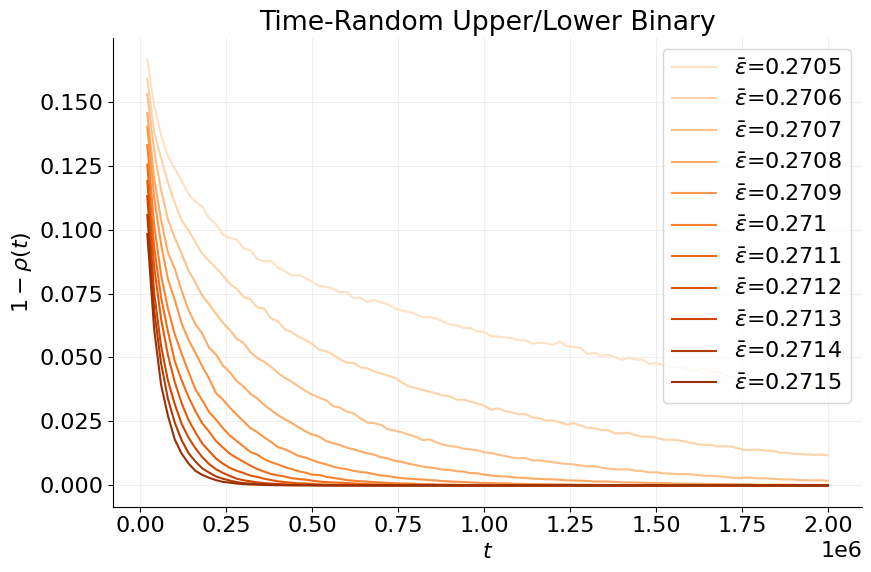

In [37]:
for L_val in L_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        ax.plot(time_vals[key], 1 - mean_rhos[key], color=cmap(i + 2), label=fr"{control_label}={control_val}")
    ax.set_title(model_label)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$1 - \rho(t)$")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_ROOT / "rho_per_time.png", dpi=200)
    plt.show()


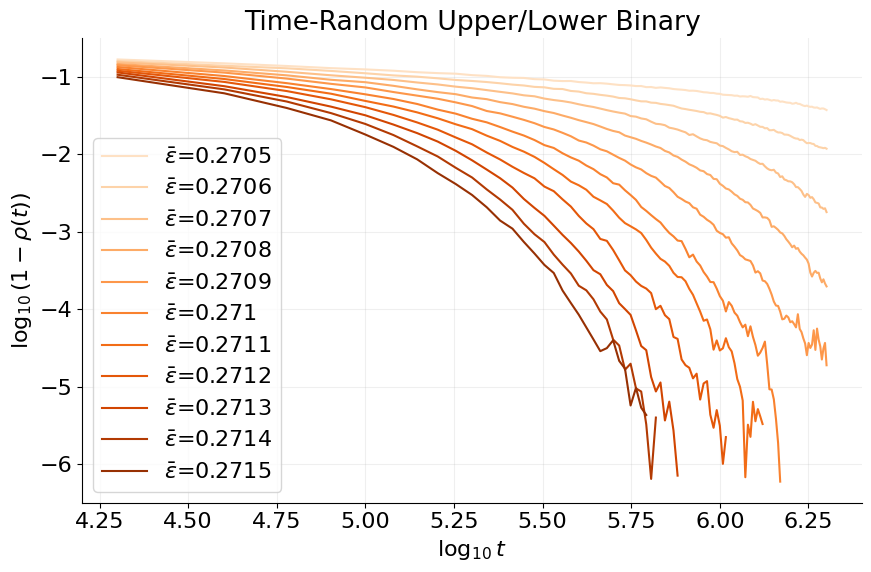

In [40]:
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
for L_val in L_vals:
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        positive = (time_vals[key] > 0) & (1 - mean_rhos[key] > 0)
        ax.plot(np.log10(time_vals[key][positive]), np.log10((1 - mean_rhos[key])[positive]),
                color=cmap(i + 2), label=fr"{control_label}={control_val}")
ax.set_title(model_label)
ax.set_xlabel(r"$\log_{10} t$")
ax.set_ylabel(r"$\log_{10}(1 - \rho(t))$")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_ROOT / "rho_per_time_log.png", dpi=200)
plt.show()
